In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

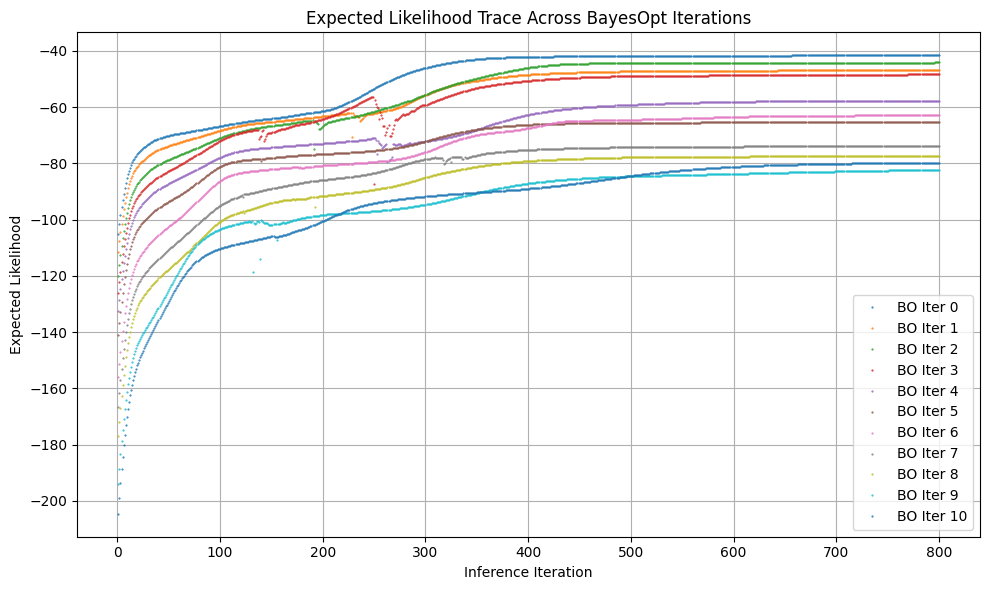

In [22]:
# Load CSV
macro = 0
df = pd.read_csv("expected_lhood.csv")

# Ensure correct ordering
df = df.sort_values(["bayesopt_iteration", "inference_iteration"])

# Get unique BayesOpt iterations
bayes_iters = sorted(df["bayesopt_iteration"].unique())

# -----------------------------
# 1. Combined plot
# -----------------------------
plt.figure(figsize=(10, 6))
df_macro = df[df["macroreplication"] == macro]
for bo_iter in bayes_iters:
    subset = df_macro[df_macro["bayesopt_iteration"] == bo_iter]

    plt.plot(
        subset["inference_iteration"],
        np.log(subset["expected_lhood"]),
        # subset["expected_lhood"],
        "o",
        markersize=0.5,
        label=f"BO Iter {bo_iter}"
    )

plt.xlabel("Inference Iteration")
plt.ylabel("Expected Likelihood")
plt.title("Expected Likelihood Trace Across BayesOpt Iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




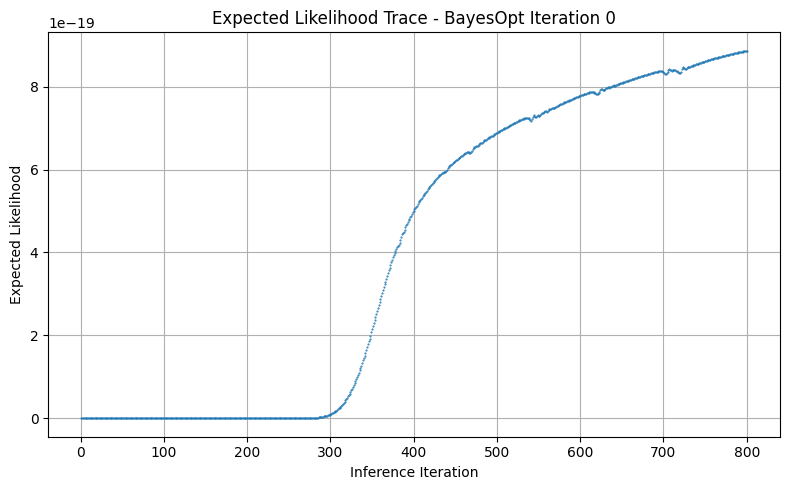

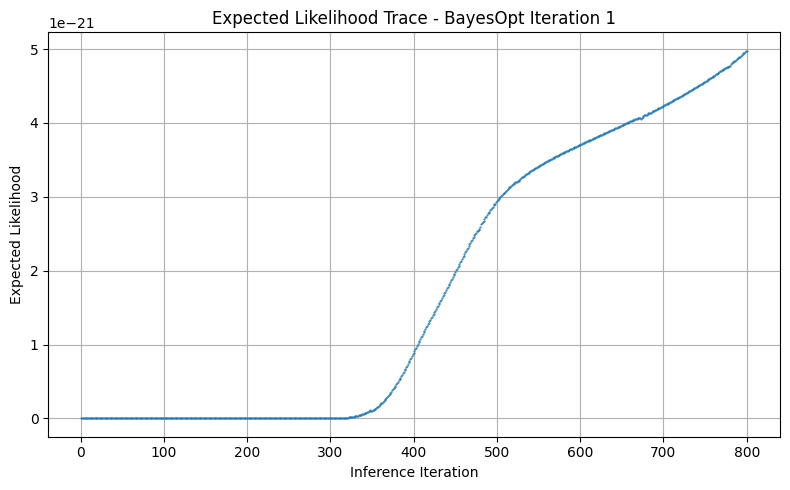

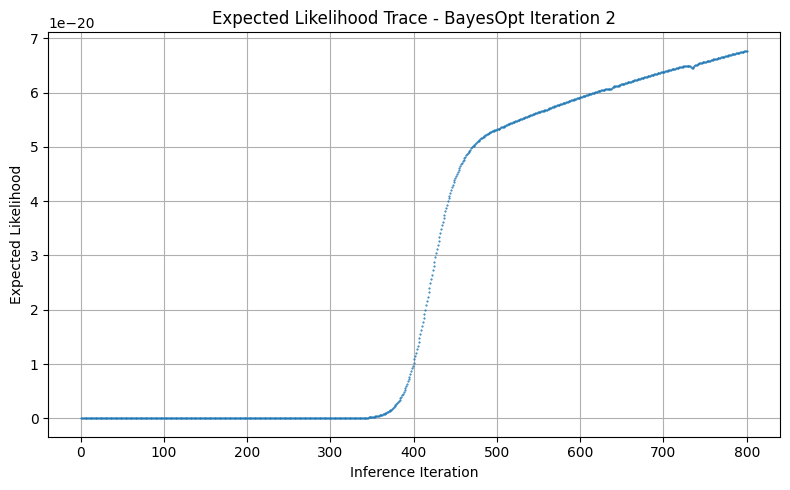

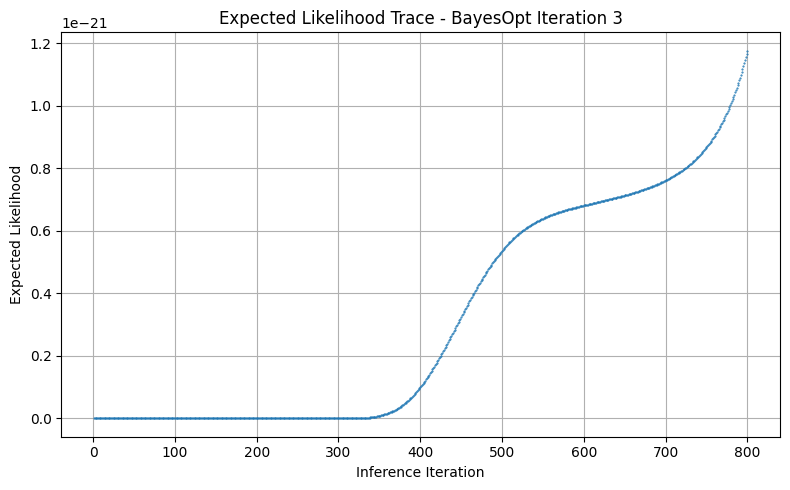

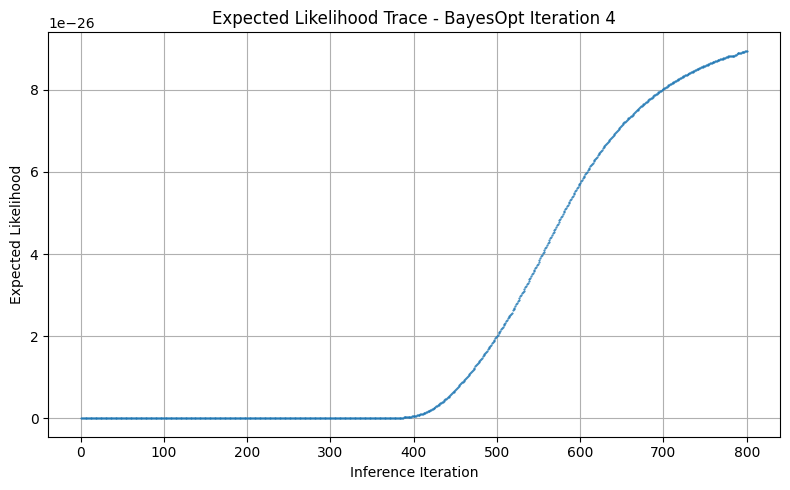

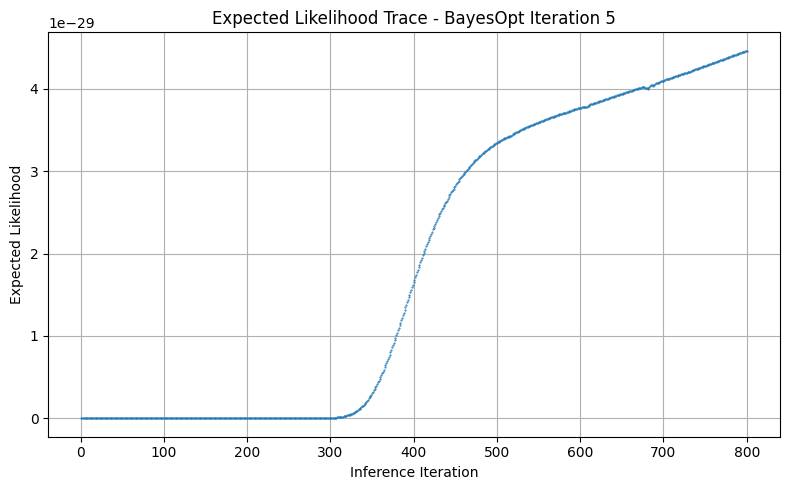

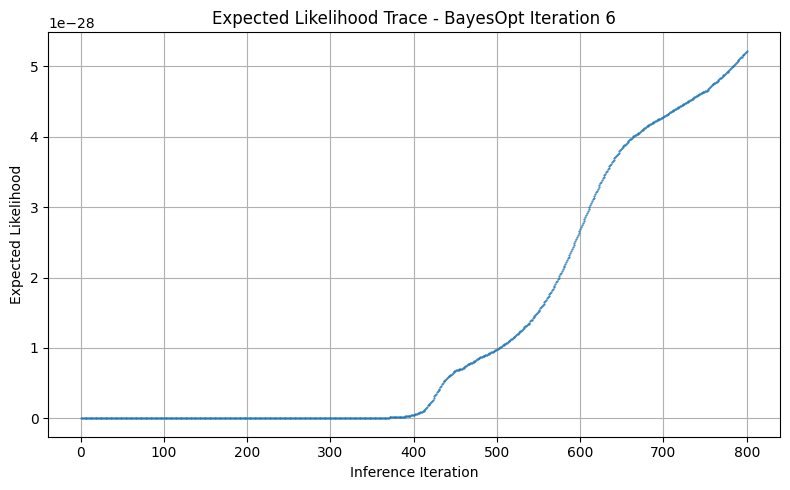

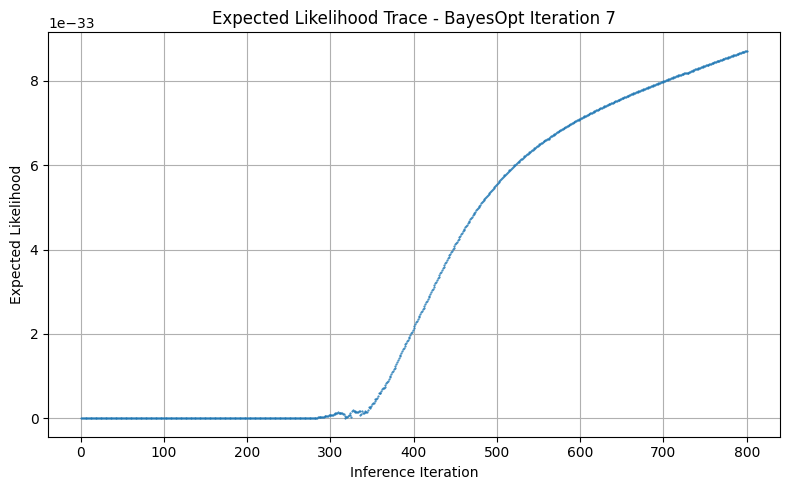

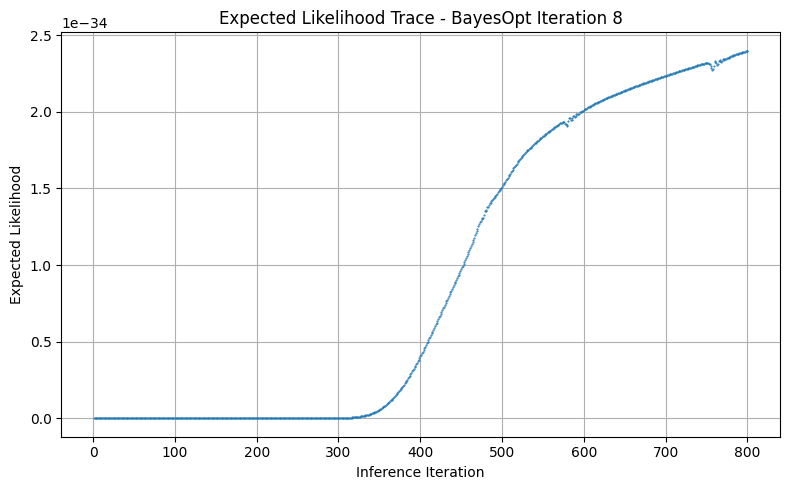

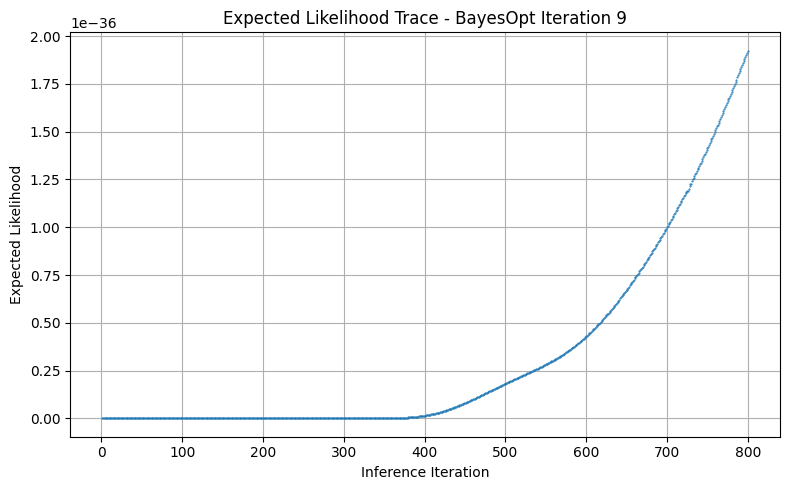

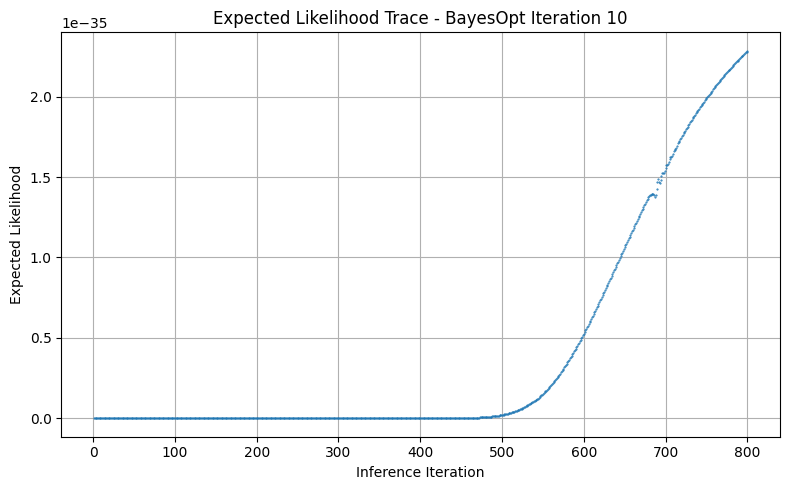

In [21]:
# -----------------------------
# 2. Separate plots
# -----------------------------
for bo_iter in bayes_iters:
    subset = df_macro[df_macro["bayesopt_iteration"] == bo_iter]

    plt.figure(figsize=(8, 5))
    plt.plot(
        subset["inference_iteration"],
        # np.log(subset["expected_lhood"]),
        subset["expected_lhood"],
        "o",
        markersize=0.5
    )

    plt.xlabel("Inference Iteration")
    plt.ylabel("Expected Likelihood")
    plt.title(f"Expected Likelihood Trace - BayesOpt Iteration {bo_iter}")
    plt.grid(True)
    plt.tight_layout()

    # Optional: save each figure
    #plt.savefig(f"expected_lhood_trace_bo_iter_{bo_iter}.png", dpi=300)

    plt.show()